

 EXPLORING DATASET: USED COMBINED CARS DATA


 Shape (Rows,Columns): (25799, 9)

 Column Names: ['brand', 'name', 'year', 'km_driven', 'fuel_type', 'transmission', 'price', 'emi', 'city']

 Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25799 entries, 0 to 25798
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         25799 non-null  object
 1   name          25799 non-null  object
 2   year          25799 non-null  int64 
 3   km_driven     25799 non-null  object
 4   fuel_type     25799 non-null  object
 5   transmission  25799 non-null  object
 6   price         25799 non-null  object
 7   emi           25799 non-null  object
 8   city          25799 non-null  object
dtypes: int64(1), object(8)
memory usage: 1.8+ MB

 Sample Records (Head):
      brand             name  year km_driven fuel_type transmission  \
0    Maruti  Maruti Alto 800  2013    59,183    Petrol       Manual   
1      Tat

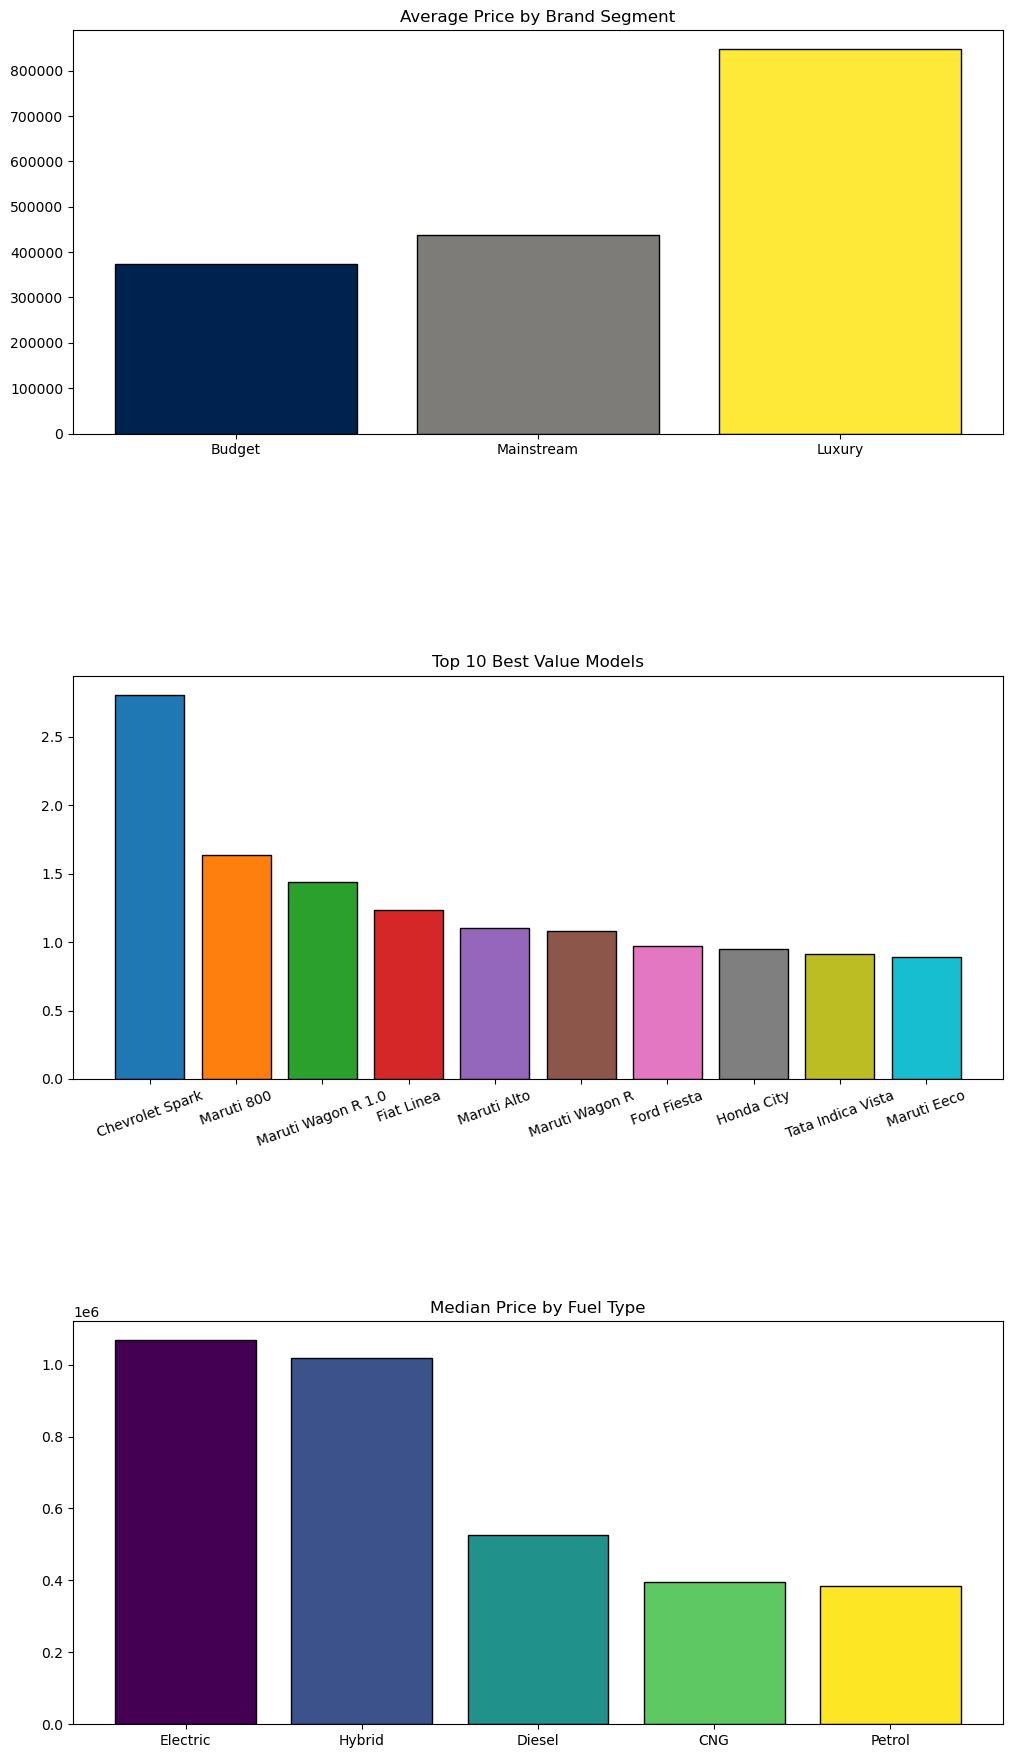


 Data Cleaned, Explored and Visualized Successfully


In [12]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

raw_folder = r"D:\DA MATERIAL\Used_Cars_Price_Analysis\Data\Raw\Cars24"
output_folder = r"D:\DA MATERIAL\Used_Cars_Price_Analysis\Data\Cleaned"
os.makedirs(output_folder, exist_ok=True)
files=glob.glob(os.path.join(raw_folder,"*.csv"))

def explore_data(df,name):
    name = name.upper() if name else "DATASET"
    print(f"\n {'=' * 70}")
    print(f"\n EXPLORING DATASET: {name}")
    print(f"\n {'=' * 70}")
    print("\n Shape (Rows,Columns):",df.shape)
    print("\n Column Names:",list(df.columns))
    print("\n Data Info:")
    df.info()
    print("\n Sample Records (Head):")
    print(df.head())
    print("\n Sample Records (Tail):")
    print(df.tail())
    print("\n Statistical Summary (Numerical):")
    print(df.describe())
    print("\n Statistical Summary(Categorical):")
    print(df.describe(include=['object','string']))
    print("\n Missing Values")
    print(df.isnull().sum())
    dup_count=df.duplicated().sum()
    print(f"\n Duplicate Rows:{dup_count}")

if not files:
    print("No CSV files found in the raw folder:")
else:
    df_list=[]
    for f in files:
        temp_df=pd.read_csv(f)
        temp_df.columns=temp_df.columns.str.strip().str.lower()
        df_list.append(temp_df)
    df=pd.concat(df_list,ignore_index=True)
    explore_data(df,"Used Combined Cars Data")
    
    count_before=len(df)
    df.drop_duplicates(inplace=True)
    count_after=len(df)
    duplicates_removed = count_before - count_after
    print("-" * 50)
    print(f"DUPPLICATION SUMMARY:")
    print(f"Rows Before: {count_before}")
    print(f"Rows After:{count_after}")
    print(f"Duplicates Removed:{duplicates_removed}")
    print("-" * 50)
    def clean_price(value):
        text = str(value).lower().strip()
        clean_text = "".join(ch for ch in text if ch.isdigit() or ch == '.')
        if not clean_text:
            return np.nan
        num=float(clean_text)
        if 'lakh' in text or num <100:
            result =round( num*100000)
        return round(result)
        
    def clean_numeric(series):
        return pd.to_numeric(series.astype(str).str.replace(r'[^\d.]','',regex=True),errors='coerce')
    if 'price' in df.columns:
        df['price']=df['price'].apply(clean_price)
    for col in ['year','km_driven','emi']:
        if col in df.columns:
            df[col]=clean_numeric(df[col])
    if 'emi' in df.columns:
        df.loc[df['emi']<1000,'emi']=np.nan
        if 'brand' in df.columns:
            df['emi']=df.groupby('brand')['emi'].transform(lambda x: x.fillna(x.median()))
        else:
            df['emi']=df['emi'].fillna(df['emi'].median())
    fuel_col='fuel_type' if 'fuel_type' in df.columns else 'fuel'
    if fuel_col in df.columns:
        df[fuel_col]= (df[fuel_col].astype(str).str.strip().str.upper().replace({'PETROL':'Petrol',
                                                                                 'DIESEL':'Diesel',
                                                                                 'ELECTRIC':'Electric',
                                                                                 'HYBRID':'Hybrid',
                                                                                 'CNG':'CNG'}))
    df.dropna(subset=['price','year'],inplace=True)
    df['km_driven']=df['km_driven'].fillna(df['km_driven'].median()).round()
    current_year=datetime.now().year
    df['car_age']=current_year-df['year']
    safe_age=df['car_age'].replace(0,1)
    df['usage_intensity']=(df['km_driven']/safe_age).round(2)
    df['value_score']=((1/(df['price']/100000))*((1/safe_age)+(1/(df['km_driven'].clip(lower=1000)/1000)))).round(4)
    if 'brand' in df.columns:
        brand_avg=df.groupby('brand')['price'].transform('mean')
        df['brand_segment']=pd.qcut(brand_avg,q=3,labels=['Budget','Mainstream','Luxury'],duplicates='drop')
    fig,axes=plt.subplots(3,1,figsize=(12,22))
    plt.subplots_adjust(hspace=0.6)
    avg_p=df.groupby('brand_segment',observed=False)['price'].mean()
    axes[0].bar(avg_p.index.astype(str),avg_p.values, color=plt.cm.cividis(np.linspace(0,1,len(avg_p))),edgecolor='black')
    axes[0].set_title("Average Price by Brand Segment")
    top_10 = df.sort_values(by='value_score', ascending=False).drop_duplicates(subset=['name']).head(10)
    axes[1].bar(top_10['name'],top_10['value_score'],color=plt.cm.tab10.colors[:len(top_10)],edgecolor='black')
    axes[1].set_title("Top 10 Best Value Models")
    axes[1].tick_params(axis='x',rotation=20)
    f_med=df.groupby(fuel_col,observed=False)['price'].median().sort_values(ascending=False)
    axes[2].bar(f_med.index,f_med.values,color=plt.cm.viridis(np.linspace(0,1,len(f_med))),edgecolor='black')
    axes[2].set_title("Median Price by Fuel Type")
    plt.show()
    output_path=os.path.join(output_folder,"Cleaned_Cars24_Data.csv")
    df.to_csv(output_path,index=False)
    print("\n Data Cleaned, Explored and Visualized Successfully")